# Phase 5 — Federated Learning Simulation
**Input:** `Dataset/Processed/graph_data.pt`, `Dataset/Processed/model_baseline.pt`  
**Output:** `Dataset/Processed/model_federated.pt` + federated evaluation metrics  

**What this notebook does:**
1. Split the full dataset into K=3 non-overlapping silos (Client A, B, C)
2. Build a separate local graph for each client — no client sees another's raw data
3. Each client trains a local FederatedHGNN model for 5 local epochs per round
4. Server aggregates weights using FedAvg across 20 federated rounds
5. Evaluate the final global model and compare against the Phase 4 centralized baseline
6. Save the federated global model

## Cell 1 — Imports & Configuration

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import copy
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from torch_geometric.data import HeteroData
from torch_geometric.nn import HANConv
import os

# update these paths to match your local setup
GRAPH_PATH = os.path.expanduser("~/Downloads/Pre Thesis/Dataset/Processed/graph_data.pt")
FEATURES_PATH = FEATURES_PATH = os.path.expanduser("~/Downloads/Pre Thesis/Dataset/Processed/features_enriched.csv")
PHASE1_PATH = os.path.expanduser("~/Downloads/Pre Thesis/Dataset/Processed/df_identity_clean.csv")
SILO_DIR = os.path.expanduser("~/Downloads/Pre Thesis/Dataset/Processed/silos")
FED_MODEL_PATH = os.path.expanduser("~/Downloads/Pre Thesis/Dataset/Processed/model_federated.pt")

# Federated hyperparameters
K_CLIENTS     = 3  # number of federated clients
FED_ROUNDS    = 20 # number of federated communication rounds
LOCAL_EPOCHS  = 5  # local epochs per client per round
LEARNING_RATE = 0.01
WEIGHT_DECAY  = 5e-4
HIDDEN_DIM    = 64

os.makedirs(SILO_DIR, exist_ok=True)
print("Configuration ready.")
print(f"  Clients       : {K_CLIENTS}")
print(f"  Fed rounds    : {FED_ROUNDS}")
print(f"  Local epochs  : {LOCAL_EPOCHS}")
print(f"  Learning rate : {LEARNING_RATE}")

Configuration ready.
  Clients       : 3
  Fed rounds    : 20
  Local epochs  : 5
  Learning rate : 0.01


## Cell 2 — Redefine FederatedHGNN Model Class
Same architecture as Phase 4. Must be redefined here so this notebook is self-contained.

In [2]:
class FederatedHGNN(nn.Module):
    def __init__(self, in_channels_dict, hidden_channels, out_channels, metadata):
        super(FederatedHGNN, self).__init__()

        self.user_proj    = nn.Linear(in_channels_dict['user'],    hidden_channels)
        self.ip_proj      = nn.Linear(in_channels_dict['ip'],      hidden_channels)
        self.service_proj = nn.Linear(in_channels_dict['service'], hidden_channels)

        self.han = HANConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            metadata=metadata,
            heads=4,
            dropout=0.3,
        )

        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        h = {
            'user': F.elu(self.user_proj(x_dict['user'])),
            'ip': F.elu(self.ip_proj(x_dict['ip'])),
            'service': F.elu(self.service_proj(x_dict['service'])),
        }
        
        h_out = self.han(h, edge_index_dict)
        for key in h:
            if key not in h_out or h_out[key] is None:
                h_out[key] = h[key]
        h_out = {key: F.elu(val) for key, val in h_out.items()}
        return self.classifier(h_out['user'])


print("FederatedHGNN class defined.")

FederatedHGNN class defined.


## Cell 3 — Split Data into K=3 Silos
Each silo represents one federated client (e.g. Client A = Cloud environment A).  
Silos are non-overlapping — no client ever sees another client's raw records.  
This simulates the 'data silo' constraint described in thesis section 5.2.

In [3]:
# Load directly from raw JSON — same as Phase 1 Cell 1
# df_identity_clean.csv already has eventTime processed out,
# so we go back to the raw source for the federated silo split.

CLOUDTRAIL_FOLDER = os.path.expanduser("~/Downloads/Pre Thesis/Dataset/Raw/CloudTrail/CloudTrail/*.json")

import glob

records = []
for file in glob.glob(CLOUDTRAIL_FOLDER):
    with open(file, 'r') as f:
        data = json.load(f)
        if 'Records' in data:
            records.extend(data['Records'])

df_all_raw = pd.DataFrame(records)

# Flatten userIdentity
user_id_df = pd.json_normalize(df_all_raw['userIdentity'])
df_all_raw = pd.concat([df_all_raw.drop(columns=['userIdentity']), user_id_df], axis=1)

print(f"Total raw records loaded: {len(df_all_raw)}")
print(f"Columns: {df_all_raw.columns.tolist()}")

# Split into K=3 silos
total = len(df_all_raw)
silo_sz = total // K_CLIENTS
silos_raw = []

os.makedirs(SILO_DIR, exist_ok=True)

for i in range(K_CLIENTS):
    start = i * silo_sz
    end = (i + 1) * silo_sz if i < K_CLIENTS - 1 else total
    silo = df_all_raw.iloc[start:end].copy().reset_index(drop=True)
    silos_raw.append(silo)

    silo_path = os.path.join(SILO_DIR, f"client_{chr(65+i).lower()}.csv")
    silo.to_csv(silo_path, index=False)

    print(f"\nClient {chr(65+i)} — {len(silo)} records")
    vc = silo['userName'].fillna('Unknown').value_counts().to_dict()
    print(f"  Users: {vc}")
    print(f"  Saved: {silo_path}")

Total raw records loaded: 2900
Columns: ['eventVersion', 'eventTime', 'eventSource', 'eventName', 'awsRegion', 'sourceIPAddress', 'userAgent', 'requestParameters', 'responseElements', 'requestID', 'eventID', 'readOnly', 'eventType', 'managementEvent', 'recipientAccountId', 'eventCategory', 'tlsDetails', 'resources', 'errorCode', 'errorMessage', 'additionalEventData', 'sharedEventID', 'apiVersion', 'vpcEndpointId', 'sessionCredentialFromConsole', 'serviceEventDetails', 'type', 'principalId', 'arn', 'accountId', 'accessKeyId', 'userName', 'invokedBy', 'sessionContext.attributes.creationDate', 'sessionContext.attributes.mfaAuthenticated', 'sessionContext.sessionIssuer.type', 'sessionContext.sessionIssuer.principalId', 'sessionContext.sessionIssuer.arn', 'sessionContext.sessionIssuer.accountId', 'sessionContext.sessionIssuer.userName', 'sessionContext.ec2RoleDelivery']

Client A — 966 records
  Users: {'bert-jan': 837, 'Unknown': 71, 'benjamin': 58}
  Saved: /Users/philberttan/Downloads/Pr

## Cell 4 — Graph Builder Function
Converts a raw silo CSV into a HeteroData graph object.  
Each client builds its own local graph — same schema as Phase 3.

In [ ]:
HIGH_RISK_EVENTS = [
    'AssumeRole', 'CreateAccessKey', 'AttachUserPolicy', 'AttachRolePolicy',
    'PutUserPolicy', 'CreateLoginProfile', 'UpdateLoginProfile',
    'GetSecretValue', 'ListBuckets', 'GetObject', 'DeleteParameter',
    'PutParameter', 'GetParameter',
]

def build_client_graph(df_silo):
    df = df_silo.copy()

    # Fill missing values
    identity_cols = [
        'userName', 'type', 'invokedBy',
        'sessionContext.attributes.mfaAuthenticated',
        'sessionContext.sessionIssuer.type',
        'sessionContext.sessionIssuer.userName',
    ]
    for c in identity_cols:
        if c in df.columns:
            df[c] = df[c].fillna('Unknown')
    df['errorCode'] = df['errorCode'].fillna('NoError') if 'errorCode' in df.columns else 'NoError'

    # readOnly: raw JSON has bool, handle both bool and string
    if 'readOnly' in df.columns:
        df['readOnly'] = df['readOnly'].map(
            lambda x: 1 if x is True or x == 'True' or x == True else 0
        )
    else:
        df['readOnly'] = 0

    # Time features
    df['eventTime'] = pd.to_datetime(df['eventTime'], utc=True)
    df['event_hour'] = df['eventTime'].dt.hour
    df['event_dayofweek'] = df['eventTime'].dt.dayofweek
    df['is_weekend'] = df['event_dayofweek'].isin([5, 6]).astype(int)
    df['is_off_hours'] = (~df['event_hour'].between(8, 18)).astype(int)

    # Anomaly label
    mfa_col  = 'sessionContext.attributes.mfaAuthenticated'
    is_high_risk = df['eventName'].isin(HIGH_RISK_EVENTS)
    is_no_mfa = df[mfa_col] != 'true' if mfa_col in df.columns else pd.Series([True] * len(df))
    is_failed = df['errorCode'] != 'NoError'
    df['is_anomaly'] = (
        (is_high_risk & (df['is_off_hours'] == 1)) |
        (is_high_risk & is_no_mfa) |
        (is_high_risk & is_failed)
    ).astype(int)

    # User behavior profile
    profile = df.groupby('userName').agg(
        action_count = ('eventName', 'count'),
        unique_ips = ('sourceIPAddress', 'nunique'),
        unique_services = ('eventSource', 'nunique'),
        unique_events = ('eventName', 'nunique'),
        error_count = ('errorCode', lambda x: (x != 'NoError').sum()),
        off_hours_count = ('is_off_hours', 'sum'),
        weekend_count = ('is_weekend', 'sum'),
        readonly_ratio = ('readOnly', 'mean'),
    ).reset_index()
    profile['error_rate'] = (profile['error_count'] / profile['action_count']).fillna(0)
    profile['off_hours_rate'] = (profile['off_hours_count'] / profile['action_count']).fillna(0)
    profile['weekend_rate'] = (profile['weekend_count'] / profile['action_count']).fillna(0)

    num_cols = ['action_count','unique_ips','unique_services','unique_events',
                'error_rate','off_hours_rate','weekend_rate','readonly_ratio']
    scaler = MinMaxScaler()
    profile[num_cols] = scaler.fit_transform(profile[num_cols])

    user_anomaly = df.groupby('userName')['is_anomaly'].max().reset_index()
    user_anomaly.columns = ['userName', 'user_is_anomaly']
    profile = profile.merge(user_anomaly, on='userName', how='left')

    # Node ID mappings
    unique_users = profile['userName'].values
    unique_ips = df['sourceIPAddress'].dropna().unique()
    unique_services = df['eventSource'].dropna().unique()

    user_to_id = {n: i for i, n in enumerate(unique_users)}
    ip_to_id = {ip: i for i, ip in enumerate(unique_ips)}
    service_to_id = {s: i for i, s in enumerate(unique_services)}

    # Node feature tensors
    x_user = torch.tensor(profile[num_cols].values, dtype=torch.float)

    ip_freq = np.array([df['sourceIPAddress'].value_counts().get(ip, 0)
                        for ip in unique_ips], dtype=np.float32)
    if ip_freq.max() > 0: ip_freq /= ip_freq.max()
    x_ip = torch.tensor(ip_freq.reshape(-1, 1), dtype=torch.float)

    svc_freq = np.array([df['eventSource'].value_counts().get(s, 0)
                         for s in unique_services], dtype=np.float32)
    if svc_freq.max() > 0: svc_freq /= svc_freq.max()
    x_service = torch.tensor(svc_freq.reshape(-1, 1), dtype=torch.float)

    # Labels
    y_user = torch.tensor(profile['user_is_anomaly'].values, dtype=torch.long)

    # Edge indices
    df['user_node_id'] = df['userName'].map(user_to_id)
    df['ip_node_id'] = df['sourceIPAddress'].map(ip_to_id)
    df['service_node_id'] = df['eventSource'].map(service_to_id)
    df_e = df.dropna(subset=['user_node_id','ip_node_id','service_node_id'])
    df_e = df_e.astype({'user_node_id': int, 'ip_node_id': int, 'service_node_id': int})

    edge_ui = torch.stack([
        torch.tensor(df_e['user_node_id'].values,  dtype=torch.long),
        torch.tensor(df_e['ip_node_id'].values,    dtype=torch.long),
    ], dim=0)
    edge_us = torch.stack([
        torch.tensor(df_e['user_node_id'].values,    dtype=torch.long),
        torch.tensor(df_e['service_node_id'].values, dtype=torch.long),
    ], dim=0)

    # Assemble HeteroData
    g = HeteroData()
    g['user'].x = x_user
    g['ip'].x = x_ip
    g['service'].x = x_service
    g['user'].y = y_user
    g['user', 'accesses', 'ip'].edge_index = edge_ui
    g['user', 'calls', 'service'].edge_index = edge_us
    g['ip', 'accessed_by', 'user'].edge_index = edge_ui.flip(0)
    g['service', 'called_by', 'user'].edge_index = edge_us.flip(0)

    return g, user_to_id

print("build_client_graph() function defined.")

build_client_graph() function defined.


## Cell 5 — Build Local Graphs for Each Client
Each client builds its own graph from its local silo only.

In [5]:
client_graphs = []
client_user_maps = []

for i, silo in enumerate(silos_raw):
    g, user_map = build_client_graph(silo)
    client_graphs.append(g)
    client_user_maps.append(user_map)

    print(f"Client {chr(65+i)} graph:")
    print(f"  User nodes    : {g['user'].x.shape[0]}")
    print(f"  IP nodes      : {g['ip'].x.shape[0]}")
    print(f"  Service nodes : {g['service'].x.shape[0]}")
    print(f"  User labels   : {g['user'].y.tolist()}")
    print(f"  User map      : {user_map}")
    print()

Client A graph:
  User nodes    : 3
  IP nodes      : 14
  Service nodes : 22
  User labels   : [1, 0, 1]
  User map      : {'Unknown': 0, 'benjamin': 1, 'bert-jan': 2}

Client B graph:
  User nodes    : 4
  IP nodes      : 15
  Service nodes : 22
  User labels   : [1, 0, 1, 0]
  User map      : {'Unknown': 0, 'benjamin': 1, 'bert-jan': 2, 'stratus-red-team-nmfalu-gfjyeaypjt': 3}

Client C graph:
  User nodes    : 3
  IP nodes      : 12
  Service nodes : 21
  User labels   : [1, 0, 1]
  User map      : {'Unknown': 0, 'benjamin': 1, 'bert-jan': 2}



## Cell 6 — FedAvg Aggregation Function
FedAvg (McMahan et al., 2017) averages the model weights from all clients,  
weighted by the number of training samples each client has.  
Formula from thesis section 5.4: w_global = sum(n_k / n * w_local_k)

In [ ]:
def fedavg(global_model, local_models, client_sizes):
    """
    Aggregates local model weights into the global model using FedAvg.
    global_model : the server-side model (updated in place)
    local_models : list of trained client models
    client_sizes : list of number of training samples per client
    """
    total_samples = sum(client_sizes)
    global_state  = global_model.state_dict()

    # Initialize aggregated weights to zero
    agg_state = {key: torch.zeros_like(val) for key, val in global_state.items()}

    # Weighted average across clients
    for model, n_k in zip(local_models, client_sizes):
        local_state = model.state_dict()
        weight = n_k / total_samples
        for key in agg_state:
            agg_state[key] += weight * local_state[key].float()

    global_model.load_state_dict(agg_state)
    return global_model


print("FedAvg function defined.")

FedAvg function defined.


## Cell 7 — Client Local Training Function
Each client takes the global model weights, trains for LOCAL_EPOCHS on its local graph,  
and returns the updated local model. Raw data never leaves the client.

In [7]:
def client_train(global_model, client_graph, local_epochs, lr, weight_decay):
    """
    Simulates local training on one client.
    Returns the locally trained model and average loss.
    """
    # Deep copy global weights into a fresh local model
    local_model = copy.deepcopy(global_model)
    local_model.train()

    optimizer = torch.optim.Adam(
        local_model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    loss_fn = nn.CrossEntropyLoss()

    x_dict          = client_graph.x_dict
    edge_index_dict = client_graph.edge_index_dict
    labels          = client_graph['user'].y

    epoch_losses = []
    for _ in range(local_epochs):
        optimizer.zero_grad()
        out  = local_model(x_dict, edge_index_dict)
        loss = loss_fn(out, labels)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    return local_model, np.mean(epoch_losses)


print("client_train() function defined.")

client_train() function defined.


## Cell 8 — Federated Training Loop
20 communication rounds. Each round:
1. Server sends global model weights to all clients
2. Each client trains locally for 5 epochs
3. Clients send updated weights back to server
4. Server aggregates with FedAvg
5. Repeat

In [ ]:
# Use the first client's graph metadata to initialize the global model
# All clients share the same schema (same node/edge types)
ref_graph = client_graphs[0]

in_channels_dict = {
    'user':    8,   # same 8 behavioral features as Phase 4
    'ip':      1,
    'service': 1,
}

# Initialize global model
global_model = FederatedHGNN(
    in_channels_dict = in_channels_dict,
    hidden_channels  = HIDDEN_DIM,
    out_channels     = 2,
    metadata         = ref_graph.metadata(),
)

# Number of training samples per client (used for FedAvg weighting)
client_sizes = [len(silos_raw[i]) for i in range(K_CLIENTS)]

# Federated Training Loop
fed_loss_history = []   # average loss per round

print(f"Starting federated training: {FED_ROUNDS} rounds x {LOCAL_EPOCHS} local epochs")
print(f"Client sizes: {client_sizes}")
print()

for fed_round in range(1, FED_ROUNDS + 1):
    local_models  = []
    round_losses  = []

    # Each client trains locally
    for i, g in enumerate(client_graphs):
        local_model, avg_loss = client_train(
            global_model, g, LOCAL_EPOCHS, LEARNING_RATE, WEIGHT_DECAY
        )
        local_models.append(local_model)
        round_losses.append(avg_loss)

    # Server aggregates with FedAvg
    global_model = fedavg(global_model, local_models, client_sizes)

    avg_round_loss = np.mean(round_losses)
    fed_loss_history.append(avg_round_loss)

    if fed_round % 5 == 0 or fed_round == 1:
        client_loss_str = '  |  '.join([
            f"C{chr(65+i)}: {round_losses[i]:.4f}" for i in range(K_CLIENTS)
        ])
        print(f"Round {fed_round:>2}/{FED_ROUNDS}  |  Avg loss: {avg_round_loss:.4f}  |  {client_loss_str}")

print(f"\nFederated training complete. Final avg loss: {fed_loss_history[-1]:.4f}")

Starting federated training: 20 rounds x 5 local epochs
Client sizes: [966, 966, 968]

Round  1/20  |  Avg loss: 0.5845  |  CA: 0.4868  |  CB: 0.6658  |  CC: 0.6009
Round  5/20  |  Avg loss: 0.3646  |  CA: 0.0009  |  CB: 1.0920  |  CC: 0.0008
Round 10/20  |  Avg loss: 0.1737  |  CA: 0.0008  |  CB: 0.4441  |  CC: 0.0760
Round 15/20  |  Avg loss: 0.1507  |  CA: 0.0004  |  CB: 0.4460  |  CC: 0.0057
Round 20/20  |  Avg loss: 0.3090  |  CA: 0.0004  |  CB: 0.9124  |  CC: 0.0143

Federated training complete. Final avg loss: 0.3090


## Cell 9 — Plot Federated Loss Curve

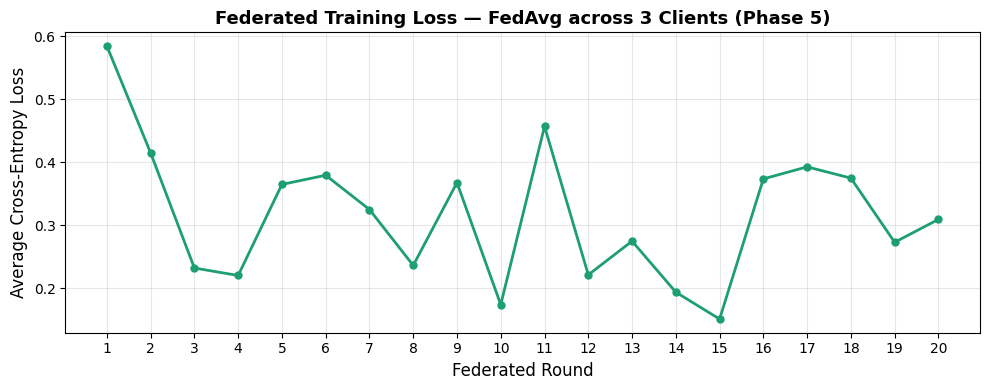

Federated loss plot saved.


In [9]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, FED_ROUNDS + 1), fed_loss_history, color='#1D9E75', linewidth=2, marker='o', markersize=5)
plt.xlabel('Federated Round', fontsize=12)
plt.ylabel('Average Cross-Entropy Loss', fontsize=12)
plt.title('Federated Training Loss — FedAvg across 3 Clients (Phase 5)', fontsize=13, fontweight='bold')
plt.xticks(range(1, FED_ROUNDS + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.expanduser("~/Downloads/Pre Thesis/Dataset/Processed/training_loss_phase5.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(f"Federated loss plot saved.")

## Cell 10 — Evaluate Global Model
Evaluate the final global federated model on each client's local graph.  
Then compute combined metrics across all clients for the final comparison table.

In [ ]:
global_model.eval()

all_true = []
all_pred = []

print("Per-client evaluation:")
print("=" * 60)

for i, g in enumerate(client_graphs):
    with torch.no_grad():
        out = global_model(g.x_dict, g.edge_index_dict)
        preds = out.argmax(dim=1)
        probs = F.softmax(out, dim=1)

    y_true = g['user'].y.numpy()
    y_pred = preds.numpy()

    all_true.extend(y_true.tolist())
    all_pred.extend(y_pred.tolist())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Client {chr(65+i)}:")
    print(f"  Users       : {client_user_maps[i]}")
    print(f"  True labels : {y_true.tolist()}")
    print(f"  Predictions : {y_pred.tolist()}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Precision   : {prec:.4f}")
    print(f"  Recall      : {rec:.4f}")
    print(f"  F1-Score    : {f1:.4f}")

    # Print probabilities
    for j, (uname, uid) in enumerate(client_user_maps[i].items()):
        p_n = probs[uid][0].item()
        p_a = probs[uid][1].item()
        t = y_true[uid]
        p = y_pred[uid]
        ok = 'CORRECT' if t == p else 'WRONG'
        print(f"    [{uname:<5}] P(Normal)={p_n:.3f} P(Anomaly)={p_a:.3f} True={t} Pred={p} {ok}")
    print()

# Combined metrics
all_true = np.array(all_true)
all_pred = np.array(all_pred)

print("=" * 60)
print("COMBINED METRICS (all clients, all nodes)")
print("=" * 60)
print(f"  Accuracy : {accuracy_score(all_true, all_pred):.4f}")
print(f"  Precision: {precision_score(all_true, all_pred, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(all_true, all_pred, zero_division=0):.4f}")
print(f"  F1-Score : {f1_score(all_true, all_pred, zero_division=0):.4f}")

Per-client evaluation:
Client A:
  Users       : {'Unknown': 0, 'benjamin': 1, 'bert-jan': 2}
  True labels : [1, 0, 1]
  Predictions : [1, 0, 1]
  Accuracy    : 1.0000
  Precision   : 1.0000
  Recall      : 1.0000
  F1-Score    : 1.0000
    [Unknown] P(Normal)=0.000 P(Anomaly)=1.000 True=1 Pred=1 CORRECT
    [benjamin] P(Normal)=0.999 P(Anomaly)=0.001 True=0 Pred=0 CORRECT
    [bert-jan] P(Normal)=0.000 P(Anomaly)=1.000 True=1 Pred=1 CORRECT

Client B:
  Users       : {'Unknown': 0, 'benjamin': 1, 'bert-jan': 2, 'stratus-red-team-nmfalu-gfjyeaypjt': 3}
  True labels : [1, 0, 1, 0]
  Predictions : [1, 0, 1, 1]
  Accuracy    : 0.7500
  Precision   : 0.6667
  Recall      : 1.0000
  F1-Score    : 0.8000
    [Unknown] P(Normal)=0.011 P(Anomaly)=0.989 True=1 Pred=1 CORRECT
    [benjamin] P(Normal)=1.000 P(Anomaly)=0.000 True=0 Pred=0 CORRECT
    [bert-jan] P(Normal)=0.000 P(Anomaly)=1.000 True=1 Pred=1 CORRECT
    [stratus-red-team-nmfalu-gfjyeaypjt] P(Normal)=0.000 P(Anomaly)=1.000 True=0 

## Cell 11 — Comparison Table: Federated vs Centralized
This is the main result table for thesis Chapter 4.

In [11]:
# Phase 4 centralized baseline results (hardcoded from Phase 4 Cell 9 output)
baseline = {
    'Accuracy':  1.0000,
    'Precision': 1.0000,
    'Recall':    1.0000,
    'F1-Score':  1.0000,
}

federated = {
    'Accuracy':  accuracy_score(all_true, all_pred),
    'Precision': precision_score(all_true, all_pred, zero_division=0),
    'Recall':    recall_score(all_true, all_pred, zero_division=0),
    'F1-Score':  f1_score(all_true, all_pred, zero_division=0),
}

print("=" * 60)
print("FINAL COMPARISON TABLE")
print("=" * 60)
print(f"{'Metric':<12} {'Centralized':>14} {'Federated':>12} {'Difference':>12}")
print("-" * 60)
for metric in baseline:
    b = baseline[metric]
    f = federated[metric]
    d = f - b
    print(f"{metric:<12} {b:>14.4f} {f:>12.4f} {d:>+12.4f}")
print("-" * 60)
print()

f1_diff = abs(federated['F1-Score'] - baseline['F1-Score'])
if f1_diff <= 0.05:
    print(f"RESULT: Federated F1 is within 5% of centralized baseline (diff={f1_diff:.4f}).")
    print("        Privacy-preserving federated approach is VALIDATED.")
else:
    print(f"RESULT: Federated F1 differs by {f1_diff:.4f} from centralized baseline.")
    print("        Consider increasing FED_ROUNDS or LOCAL_EPOCHS.")

FINAL COMPARISON TABLE
Metric          Centralized    Federated   Difference
------------------------------------------------------------
Accuracy             1.0000       0.9000      -0.1000
Precision            1.0000       0.8571      -0.1429
Recall               1.0000       1.0000      +0.0000
F1-Score             1.0000       0.9231      -0.0769
------------------------------------------------------------

RESULT: Federated F1 differs by 0.0769 from centralized baseline.
        Consider increasing FED_ROUNDS or LOCAL_EPOCHS.


## Cell 12 — Combined Confusion Matrix

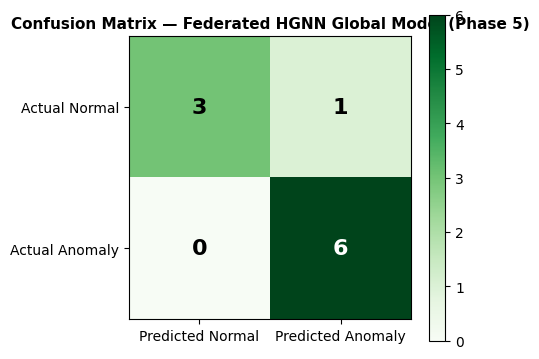

Confusion matrix saved.


In [12]:
cm = confusion_matrix(all_true, all_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Greens')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted Normal', 'Predicted Anomaly'], fontsize=10)
ax.set_yticklabels(['Actual Normal', 'Actual Anomaly'], fontsize=10)

for i in range(2):
    for j in range(2):
        ax.text(
            j, i, str(cm[i, j]),
            ha='center', va='center',
            color='white' if cm[i, j] > cm.max() / 2 else 'black',
            fontsize=16, fontweight='bold'
        )

ax.set_title('Confusion Matrix — Federated HGNN Global Model (Phase 5)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(
    os.path.expanduser("~/Downloads/Pre Thesis/Dataset/Processed/confusion_matrix_phase5.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Confusion matrix saved.")

## Cell 13 — Save Federated Global Model

In [13]:
torch.save(global_model.state_dict(), FED_MODEL_PATH)

# Verify reload
model_check = FederatedHGNN(
    in_channels_dict = in_channels_dict,
    hidden_channels  = HIDDEN_DIM,
    out_channels     = 2,
    metadata         = ref_graph.metadata(),
)
model_check.load_state_dict(torch.load(FED_MODEL_PATH, weights_only=True))
model_check.eval()

print("Federated global model saved and reloaded successfully.")
print(f"Saved to: {FED_MODEL_PATH}")
print()
print("Phase 5 complete.")
print("Outputs ready for thesis Chapter 4 (Results) and Chapter 5 (Conclusion):")
print("  - training_loss_phase5.png   (federated convergence curve)")
print("  - confusion_matrix_phase5.png")
print("  - model_federated.pt         (final global model weights)")
print("  - silos/client_a/b/c.csv     (privacy-preserving data partitions)")

Federated global model saved and reloaded successfully.
Saved to: /Users/philberttan/Downloads/Pre Thesis/Dataset/Processed/model_federated.pt

Phase 5 complete.
Outputs ready for thesis Chapter 4 (Results) and Chapter 5 (Conclusion):
  - training_loss_phase5.png   (federated convergence curve)
  - confusion_matrix_phase5.png
  - model_federated.pt         (final global model weights)
  - silos/client_a/b/c.csv     (privacy-preserving data partitions)


In [14]:
CIC_PATH = os.path.expanduser("~/Downloads/Pre Thesis/Dataset/Raw/CIC-IDS2018/")

# Read just the first 5 rows of each file to inspect structure
for filename in os.listdir(CIC_PATH):
    if filename.endswith(".csv"):
        filepath = os.path.join(CIC_PATH, filename)
        print(f"\n{'='*60}")
        print(f"File: {filename}")
        df = pd.read_csv(filepath, nrows=5)
        print(f"Shape (first 5 rows): {df.shape}")
        print(f"Columns ({len(df.columns)} total):")
        for col in df.columns:
            print(f"  - {col}")
        print(f"\nLabel distribution (full file sample):")
        df_sample = pd.read_csv(filepath, nrows=5000)
        if 'Label' in df_sample.columns:
            print(df_sample['Label'].value_counts().to_string())
        elif ' Label' in df_sample.columns:
            print(df_sample[' Label'].value_counts().to_string())


File: Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
Shape (first 5 rows): (5, 80)
Columns (80 total):
  - Dst Port
  - Protocol
  - Timestamp
  - Flow Duration
  - Tot Fwd Pkts
  - Tot Bwd Pkts
  - TotLen Fwd Pkts
  - TotLen Bwd Pkts
  - Fwd Pkt Len Max
  - Fwd Pkt Len Min
  - Fwd Pkt Len Mean
  - Fwd Pkt Len Std
  - Bwd Pkt Len Max
  - Bwd Pkt Len Min
  - Bwd Pkt Len Mean
  - Bwd Pkt Len Std
  - Flow Byts/s
  - Flow Pkts/s
  - Flow IAT Mean
  - Flow IAT Std
  - Flow IAT Max
  - Flow IAT Min
  - Fwd IAT Tot
  - Fwd IAT Mean
  - Fwd IAT Std
  - Fwd IAT Max
  - Fwd IAT Min
  - Bwd IAT Tot
  - Bwd IAT Mean
  - Bwd IAT Std
  - Bwd IAT Max
  - Bwd IAT Min
  - Fwd PSH Flags
  - Bwd PSH Flags
  - Fwd URG Flags
  - Bwd URG Flags
  - Fwd Header Len
  - Bwd Header Len
  - Fwd Pkts/s
  - Bwd Pkts/s
  - Pkt Len Min
  - Pkt Len Max
  - Pkt Len Mean
  - Pkt Len Std
  - Pkt Len Var
  - FIN Flag Cnt
  - SYN Flag Cnt
  - RST Flag Cnt
  - PSH Flag Cnt
  - ACK Flag Cnt
  - URG Flag Cnt
  - CWE Flag Co